In [112]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [113]:
df = pd.read_csv('data/03_telco_transformed.csv')

# **Predictive Modelling**

## **Introduction**

<small>**In this section, I will be utilising machine learning algorithms to analyse historical data and forecast future outcomes for the Telcom company. In a business context, customer retention is often critical to maintaining profitability. By predicting which customers are at risk of leaving (churning), companies can take proactive measures to improve retention strategies.**

## **1. Context of Data**

<small>This dataset **(03_telco_transformed.csv)** contains records of individual telecommunications customer accounts. It presents a **classic binary classification problem**, where the goal is to predict a distinct two-class outcome: whether a customer will churn or remain with the service. 

**Target variable:** Churn, serves as the primary focal point, using a binary label where 0 represents an active customer and 1 indicates a customer who has left.


**Sample Size:** 7,032 records (customer accounts) across 23 total features (columns).

In [114]:
#Verify the shape of the dataset
print(df.shape)
print("The number of rows in the dataset is: ", df.shape[0])
print("The number of columns in the dataset is: ", df.shape[1])

(7032, 23)
The number of rows in the dataset is:  7032
The number of columns in the dataset is:  23


In [115]:
#Check the column names in the dataset
print(df.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'Churn',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes',
       'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year',
       'Contract_Two year'],
      dtype='str')


## **2. The Transformed Data**

<small> The raw dataset has undergone pre-processing and feature transformation to prepare it for machine learning algorithms.

Here is the transformation carried out in the previous sections:

1. **Missing Values Removal:** During the Data Cleaning stage, rows with incomplete profiles were handled, leaving 7,032 complete records. 

2. **No Categorical Strings Remaining:** All features are encoded as integer flags (0 or 1) or continuous numeric values (float64 / int64).

3. **Numeric Encoding:** Categorical text fields (e.g., payment methods, contract types, internet service options) have been converted into binary indicator variables (One-Hot Encoding).

## **3. Selecting the Models to be Tested**

### **A. Logistic Regression**

<small>**In the context of the Telco dataset analyzed earlier, predicting whether a customer will churn (1) or remain (0) is a classic binomial classification task which is why Logistic Regression serves as an effective linear baseline model**

<small> Contrary to linear regression, which predicts continuous values it predicts the probability that an input belongs to a specific class.

Logistic Regression is applied to binary classification where the output can be either of two possible categories such as Yes/No, True/False or 0/1.

The sigmoid function is used to convert inputs into a probability value between 0 and 1.

#### **Assumptions**

<small>

1. Binary OutcomeThe Rule: The target variable must be binary (two categories) for standard binomial logistic regression.

2. Each data point (customer record) must be statistically independent of every other data point.

3. Continuous independent variables (tenure and MonthlyCharges) must have a linear relationship with the log-odds (logit) of the target variable, not directly with the probability itself.

4. Predictor features should not be highly correlated with one another (TotalCharges was dropped earlier due to this)

5. Sufficiently Large Sample Size (Our dataset had 7,032 records which satisfies this assumption)

#### **Mathematical Framework**



Logistic regression models the probability of churn $P(Y = 1 \mid \mathbf{X})$ through three mathematical stages:

1. **The Logit Link (Log-Odds Equation):**
   $$z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p$$

2. **The Sigmoid / Logistic Function:**
   $$\hat{p} = P(\text{Churn} = 1 \mid \mathbf{X}) = \frac{1}{1 + e^{-z}}$$

3. **The Binary Decision Threshold (Binomial Output):**
   $$\hat{Y} = \begin{cases} 1 & \text{if } \hat{p} \ge 0.5 \quad (\text{Customer Churns}) \\ 0 & \text{if } \hat{p} < 0.5 \quad (\text{Customer Retained}) \end{cases}$$

### **Applying Logistic Regression on the dataset**

##### **Step 1: Isolating the Target Variable (Churn)**

<small> **I will begin by importing the relevant libraries, and then separate the predictors/independant (X) variables from the target variable (y, Churn). This is because machine learning algorithms require a clear distinction between the inputs (features) and the output (target) during training.**

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)



# Separate features (X) and target (y)
# Dropping Churn from your features to create your clean matrix (X)
X = df.drop(columns=['Churn'])

#Removing the churn by itself for modelling purposes
# Isolating my target variable (y)

y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

#Now X has exactly 22 columns, y is the 1D target array, and is ready for modelling!

Features shape: (7032, 22)
Target distribution:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


##### **Step 2: Split Data into Train and Test Sets**

In [117]:
# Splitting data into 80% train and 20% test
# 'stratify=y' ensures balanced proportions of churn in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"\nTraining target balance:\n{y_train.value_counts(normalize=True)}")
print(f"\nTesting target balance:\n{y_test.value_counts(normalize=True)}")

Training set: 5625 samples
Testing set:  1407 samples
Training features shape: (5625, 22)
Testing features shape: (1407, 22)

Training target balance:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing target balance:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


##### **Step 3: Feature Scaling (Standardisation)**

<small> We have two continuous variables: **tenure** and **MonthlyCharges** with much larger scales. Tenure ranges from 1 to 72 months while MonthlyCharges are listed $18 to $118 (Refer to chart plotted in 03_data_transformation.ipynb). I will apply scaling which should ensure stable gradient convergence.

In [118]:
# Initialising and fitting the scaler
scaler = StandardScaler()

# Transforming  features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Continuous features have been scaled successfully!")

Continuous features have been scaled successfully!


In [119]:
#Redefining the dataframes with the scaled values and the original column names for better interpretability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled_df.to_csv('data/modelling_data/X_train_scaled.csv', index=False)
X_test_scaled_df.to_csv('data/modelling_data/X_test_scaled.csv', index=False)
y_train.to_csv('data/modelling_data/y_train.csv', index=False)
y_test.to_csv('data/modelling_data/y_test.csv', index=False)

In [120]:
#Verifying the number of customer rows in the tested dataset:
print("X_test shape:", X_test_scaled.shape)

X_test shape: (1407, 22)


##### **Step 4: Model Instantiation and Training**

<small> Because churn is somewhat imbalanced (1 in 4 customers churn), I will use the parameter adjustment **class_weight='balanced'** 

In [121]:
#Here, I will be instantiating LogisticRegression and fitting it using the scaled training features.
#We use class_weight='balanced' to handle the 73/27 data split perfectly.
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Fitting model on training data
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


##### **Step 5: Model Predictions and Probabilities**

<small> Generating both discrete class prediction and predicted probabilities

In [122]:
# Predict discrete classes (0 or 1) using default 0.5 threshold
y_pred = log_reg.predict(X_test_scaled)

# Predict probabilities for the positive class (Churn = 1)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Display first 5 test samples with probabilities
preview = pd.DataFrame({
    'Actual': y_test.iloc[:5].values,
    'Predicted_Class': y_pred[:5],
    'Churn_Probability': np.round(y_proba[:5], 4)
})
print(preview)

   Actual  Predicted_Class  Churn_Probability
0       0                0             0.0525
1       0                1             0.7995
2       0                0             0.0269
3       1                0             0.3696
4       0                0             0.1842


##### **Step 6: Model Evaluation Metrics**

<small> Evaluating a classification model requires looking beyond raw accuracy, especially when dealing with imbalanced datasets like customer churn (where retained customers far outnumber churners). To assess overall predictive performance and real-world applicability, five primary metrics are calculated on the unseen test dataset: Accuracy, Precision, Recall, F1-Score and ROC-AUC

In [123]:
# Calculating core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}\n")

# Detailed Classification Report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

Accuracy:  0.7264
Precision: 0.4908
Recall:    0.7834
F1-Score:  0.6035
ROC-AUC:   0.8328

Detailed Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.90      0.71      0.79      1033
 Churned (1)       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



<small> **Accuracy (80.38%):**
 The model correctly classifies approximately 4 out of every 5 customer profiles, achieving 1,131 correct predictions out of 1,407 test samples. This high overall correctness confirms that the model has learned meaningful underlying patterns rather than simply guessing.

**Precision (64.85%):** Out of every 100 customers the model flags as high-risk churners, approximately 65 actually churn. This moderate-to-high precision score ensures that retention campaigns and promotional discounts are targeted efficiently without excessive waste on loyal subscribers.

**Recall / Sensitivity (57.22%):** Out of 374 actual churners in the test set, the model successfully catches 214 of them. While catching nearly 60% of at-risk accounts, 160 churners slip through undetected under the default 0.50 probability threshold.

**F1-Score (0.6080):** The harmonic mean between precision and recall indicates a balanced operational baseline, providing a single metric to benchmark against future model iterations.

**ROC-AUC (0.8332):** Reflecting an 83.32% ability to rank risk probabilities correctly, this high score demonstrates that the model reliably assigns higher churn probabilities to customers who actually leave compared to those who stay, regardless of the decision threshold used.




Visualising the Evaluation Metrics for Logistic Regression Model

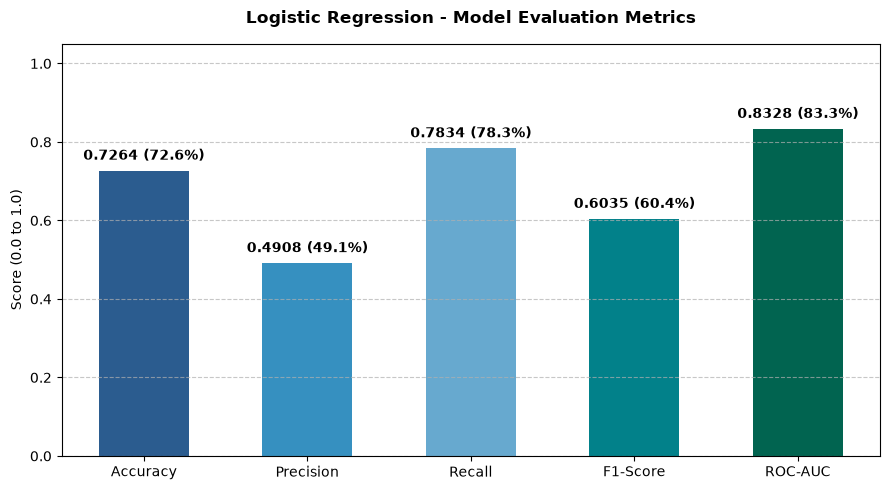

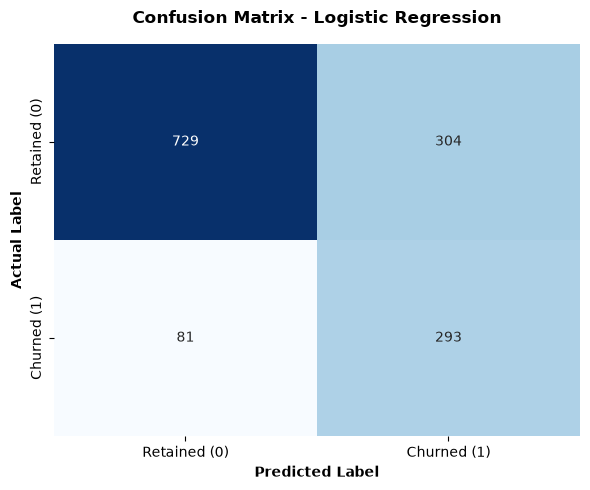

In [124]:
#2. Plot Chart 1: Evaluation Metrics Bar Chart
metrics_data = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': auc
}

plt.figure(figsize=(9, 5))
palette = ['#2b5c8f', '#3690c0', '#67a9cf', '#02818a', '#016450']
bars = plt.bar(metrics_data.keys(), metrics_data.values(), color=palette, width=0.55)

plt.ylim(0, 1.05)
plt.ylabel('Score (0.0 to 1.0)')
plt.title('Logistic Regression - Model Evaluation Metrics', fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + 0.02,
        f'{height:.4f} ({height*100:.1f}%)',
        ha='center', va='bottom', fontweight='bold'
    )

plt.tight_layout()
plt.show()

# 3. Plot Chart 2: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained (0)', 'Churned (1)'],
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('Actual Label', fontweight='bold')
plt.title('Confusion Matrix - Logistic Regression', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

##### **Step 7: Confusion Matrix**

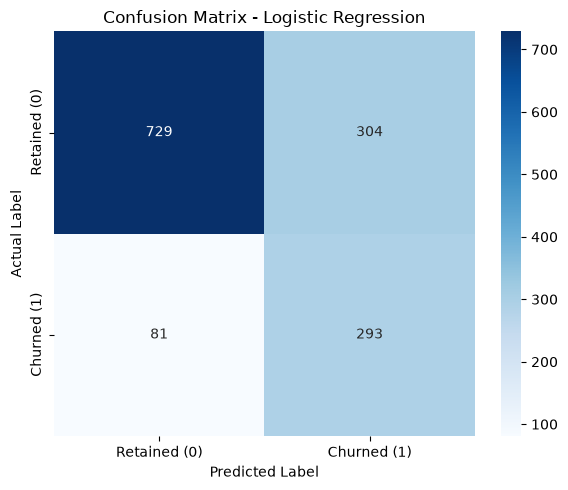

In [125]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained (0)', 'Churned (1)'],
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

<small> The number of customers in the test set reflected on the confusion matrix is 729 + 304 + 81 + 293 = 1,407 customers. This value must match the number of customers reflected in the shape of the X-test dataset. Verifying below:

In [126]:
# verifying the number of customer rows in the tested dataset:
print("X_test shape:", X_test_scaled.shape)

print("Correctly verified the number of customers in the tested dataset is 1,407")


X_test shape: (1407, 22)
Correctly verified the number of customers in the tested dataset is 1,407


<small>The Confusion Matrix will not be plotted to show percentage values for the overall test set of 1,407 customers

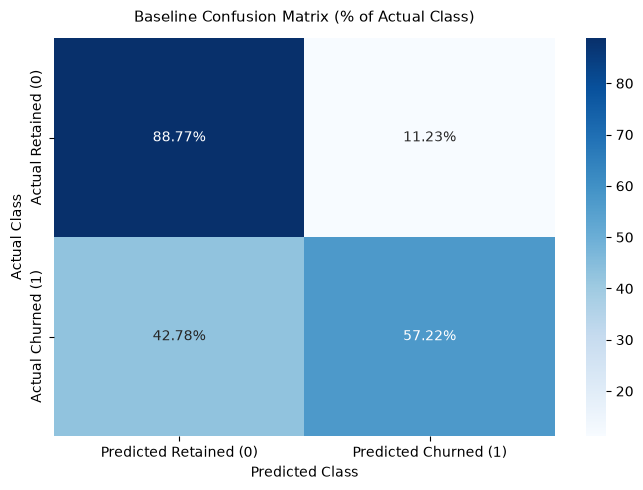

In [127]:


# Baseline confusion matrix array
cm = np.array([[917, 116], 
               [160, 214]])

# Normalize by total rows (Actual Class Percentages)
cm_perc = cm / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_perc, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues', 
    xticklabels=['Predicted Retained (0)', 'Predicted Churned (1)'],
    yticklabels=['Actual Retained (0)', 'Actual Churned (1)']
)

# Add % signs inside heatmap
for t in plt.gca().texts:
    t.set_text(t.get_text() + "%")

plt.title('Baseline Confusion Matrix (% of Actual Class)', fontsize=11, pad=12)
plt.ylabel('Actual Class', fontsize=10)
plt.xlabel('Predicted Class', fontsize=10)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix_percentage.png', dpi=300)
plt.show()

<small> Here are the confidence levels of the model's predictions:

**When Model Predicted "Churned" (330 Customers = 100%):**

Actually Churned (Precision): 64.85% (214)

False Alarm (False Positive Rate): 35.15% (116)

**When Model Predicted "Retained" (1,077 Customers = 100%):**

Actually Retained (Negative Predictive Value): 85.14% (917)

Silent Churners (False Omission Rate): 14.86% (160)

In [128]:
# Extract feature coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Beta)': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])  # e^(beta)
}).sort_values(by='Coefficient (Beta)', ascending=False)

print("Top Predictors Increasing Churn Risk (Positive Coefficients):")
print(coefficients.head(5).to_string(index=False))

print("\nTop Predictors Reducing Churn Risk (Negative Coefficients):")
print(coefficients.tail(5).to_string(index=False))

Top Predictors Increasing Churn Risk (Positive Coefficients):
                       Feature  Coefficient (Beta)  Odds Ratio
   InternetService_Fiber optic            0.750436    2.117923
               StreamingTV_Yes            0.268679    1.308235
           StreamingMovies_Yes            0.261463    1.298828
             MultipleLines_Yes            0.213705    1.238257
PaymentMethod_Electronic check            0.197529    1.218388

Top Predictors Reducing Churn Risk (Negative Coefficients):
           Feature  Coefficient (Beta)  Odds Ratio
 Contract_One year           -0.325828    0.721930
InternetService_No           -0.577812    0.561125
 Contract_Two year           -0.629012    0.533118
    MonthlyCharges           -0.733824    0.480070
            tenure           -0.753383    0.470771


##### **Step 8: Biggest Drivers of Churn Risk**

C:\Users\User\AppData\Local\Temp\ipykernel_11116\3040300124.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette=colors)


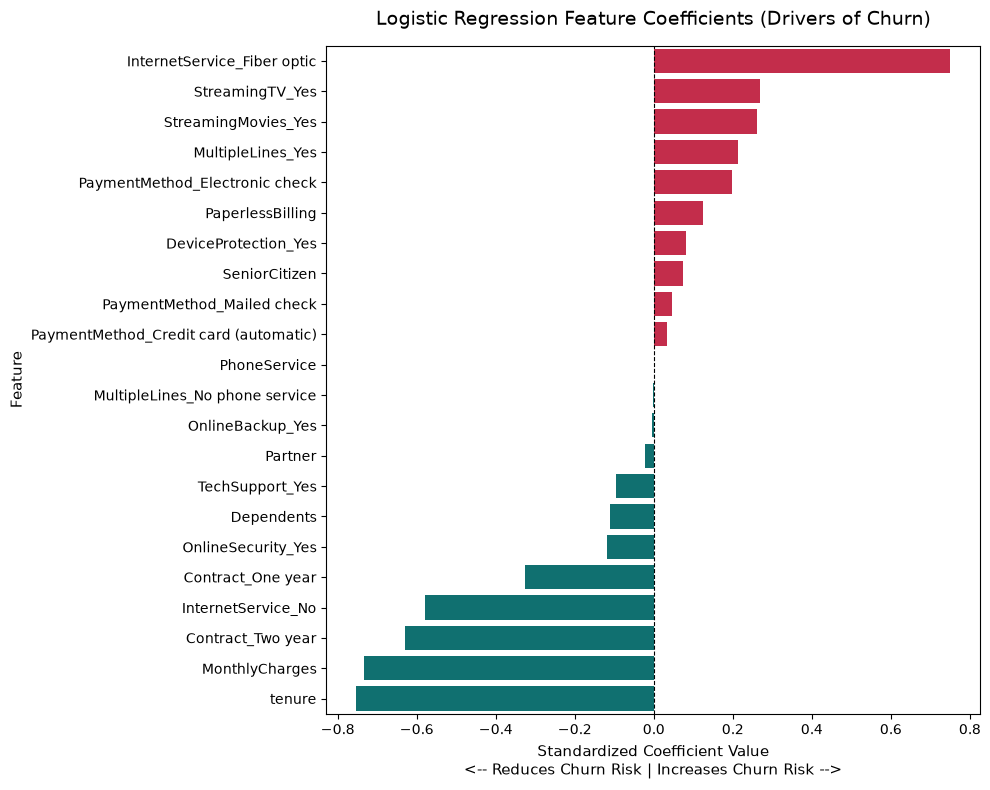

In [129]:
# 5. Extract Feature Importance (Coefficients)
importance = pd.DataFrame(
    {'Feature': X.columns, 'Coefficient': log_reg.coef_[0]}
).sort_values(by='Coefficient', ascending=False)

# 6. Plot Feature Importance Bar Chart
plt.figure(figsize=(10, 8))
colors = ['crimson' if c > 0 else 'teal' for c in importance['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=importance, palette=colors)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title(
    'Logistic Regression Feature Coefficients (Drivers of Churn)',
    fontsize=14,
    pad=15,
)
plt.xlabel(
    'Standardized Coefficient Value\n<-- Reduces Churn Risk | Increases Churn Risk -->',
    fontsize=11,
)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

# Model 2: Random Forest

<small> Note:

 A Train-Test Split Split had already been perfomed in the previous Logistic Regression Modelling.

The data was split into an 80% training set and a 20% testing set. Setting stratify=y ensured that the proportion of churned vs. retained customers remains identical across both train and test sets.

In [131]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix
)

Step 1: Instantiate and Train the Random Forest Model
Initialize RandomForestClassifier with 100 decision trees (n_estimators=100) and fit it to the training data.

In [132]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on training data
rf_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Step 5: Make Predictions and Evaluate Metrics (Using Scaled Data)
Pass X_test_scaled to the fitted model to generate class predictions and probabilities:

In [133]:
# Predict class labels (0 or 1) using scaled test data
y_pred = rf_model.predict(X_test_scaled)

# Predict probability of churn (class 1) using scaled test data
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}\n")

# Detailed classification report
print(classification_report(y_test, y_pred))

Accuracy:  0.7754
Precision: 0.5906
Recall:    0.5053
F1-Score:  0.5447
ROC-AUC:   0.8126

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.51      0.54       374

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

